# **Verificação formal para multiplicação de inteiros**
### Trabalho prático 2 - Grupo 16

O objetivo deste trabalho foi verificar formalmente as propriedades de um algoritmo de multiplicação de inteiros, descrito pelo seguinte código em *python*:

---
```python
assert a >= 0 and b >= 0
x , y, z = a , b , 0
while not y == 0:
  if even(y):
      x , y , z = x << 1 , y >> 1 , z
  else:
      x , y , z = x , y - 1, z + x
```
---
Este algoritmo, que calcula $z = a \cdot b$ para inteiros não-negativos $a$ e $b$, foi apresentado sob a forma de um *Control Flow Automaton* (CFA) no enuncidado.

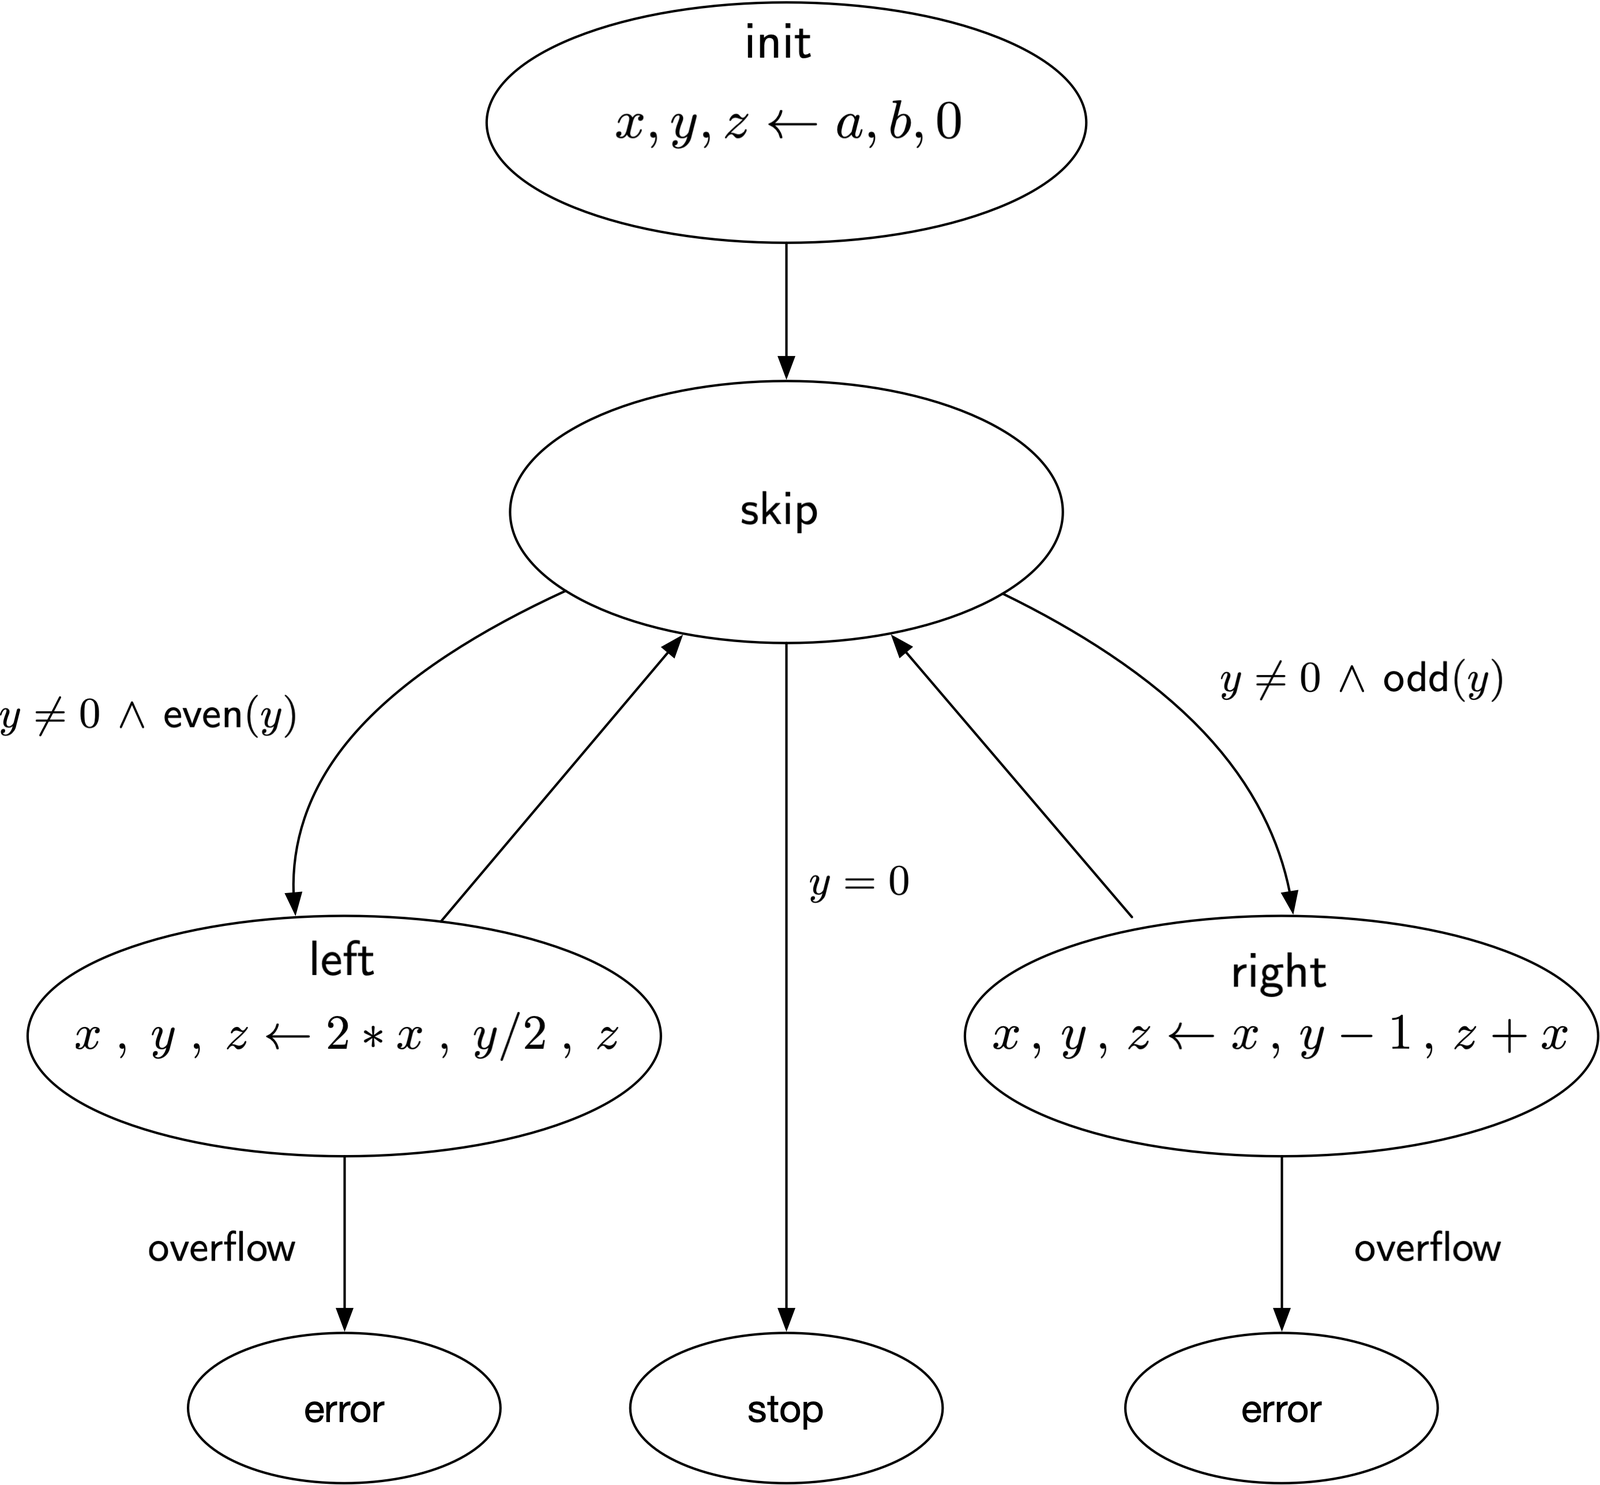


O desafio deste problema reside na verificação do programa usando a lógica de **BitVecs** (vetores de bits) de precisão limitada (`n` bits). Como os *solvers* SMT (como o *Z3*) tratam operações de **BitVecs** como totais e modulares (módulo $2^n$), elas não geram erros de *overflow*. Portanto, uma parte crucial do trabalho foi modelar manualmente as condições que, num processador real, ativariam o *bit* de *overflow*.

Para este trabalho usamos os conhecimentos adquiridos na **Ficha 7**, na qual utiliza-se o *Bounded Model Checking* (BMC) para encontrar contra-exemplos num número limitado de passos.

## Metodologia
Para a realização deste problema optamos por dividir-lo nas três tarefas sugeridas no enunciado.
1. Construção do FOTS que descreve o comportamento do autómato.
2. Verificar se $(x∗y+z=a∗b)$ é um invariante do FOTS construido.
3. Testar a segurança do programa ($N≤a,b≤M$).

## **Tarefa 1 - Modelação do FOTS**

O primeiro passo foi traduzir o diagrama CFA num modelo FOTS formal. Este modelo foi implementado usando *pySMT*.

O estado do sistema foi definido por:

- Variáveis de Dados: `a`, `b`, `x`, `y`, `z`, todas modeladas como *BVType*(`nbits`).

- Variável de Controlo: `loc`, modelada como um `BVType(3)` (suficiente para os 6 locais), para representar o nodo atual no CFA (`INIT`, `SKIP`, `LEFT`, `RIGHT`, `STOP`, `ERROR`).

In [1]:
from pysmt.shortcuts import (BV,Symbol,Solver,And,Not,Or,Equals,BVUGT,BVULE,BVULT,BVAdd,BVSub,BVAnd,BVLShl,BVLShr,BVMul)
from pysmt.typing import BVType

nbits = 8

N_LOC=3

#constantes
LOC_INIT  = BV(0, N_LOC)
LOC_SKIP  = BV(1, N_LOC)
LOC_LEFT  = BV(2, N_LOC)
LOC_RIGHT = BV(3, N_LOC)
LOC_STOP  = BV(4, N_LOC)
LOC_ERROR = BV(5, N_LOC)

def declare(i):
    state = {}
    # 'loc' é uma VARIÁVEL BitVec de tamanho N_LOC
    state['loc'] = Symbol('loc'+str(i), BVType(N_LOC))
    
    # Variáveis do problema (todas BitVec de tamanho nbits) 
    state['x'] = Symbol(f'x{i}_{nbits}', BVType(nbits))
    state['y'] = Symbol(f'y{i}_{nbits}', BVType(nbits))
    state['z'] = Symbol(f'z{i}_{nbits}', BVType(nbits))
    state['a'] = Symbol(f'a{i}_{nbits}', BVType(nbits))
    state['b'] = Symbol(f'b{i}_{nbits}', BVType(nbits))
    return state


### Estado Inicial
O Estado Inicial (`init`) define o ponto de partida do programa, e pode ser definido pelo seguinte predicado:

$$
loc = init  \wedge a > 0 \wedge b > 0 \wedge x = a \wedge y = b \wedge z = 0
$$

In [2]:
def init(state):
    return And(
        Equals(
            state['loc'],
            LOC_INIT
        ),
        BVUGT(
            state['a'],
            BV(0,nbits)
        ),
        BVUGT(
            state['b'],
            BV(0,nbits)
        ),
        Equals(
            state['x'],
            state['a']
        ),
        Equals(
            state['y'],
            state['b']
        ),
        Equals(
            state['z'],
            BV(0,nbits)
        )
    )

O Estado de Erro (`is_error`) define o estado indesejado:
$$
loc = error
$$

In [3]:
def is_error(state):
    return Equals(state['loc'], LOC_ERROR)

### Relação de Transição

A função trans define todas as "setas" possíveis do diagrama CFA.

A alteração do valor das variáveis pode ser visualizada pelo seguinte autómato:
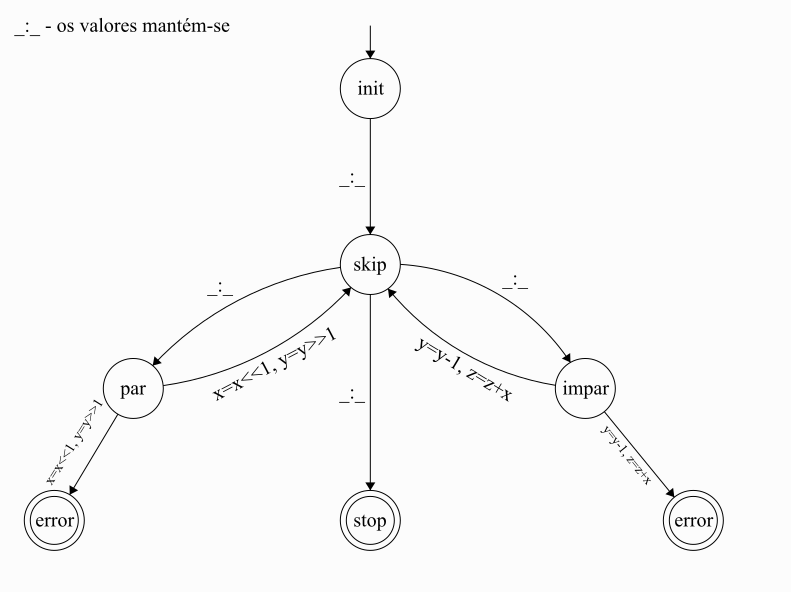

A partir deste autómato foi-nos mais fácil perceber como tínhamos de modelar as transições.

Para evitar muita repetição nas transições optamos por separar uma condição que se tem de verificar ao longo de todo o programa:

$$
a = a' \wedge b = b'
$$

In [4]:
def const_ab(curr, prox):
    return And(
        Equals(curr['a'], prox['a']),
        Equals(curr['b'], prox['b'])
    )

#### Transição `init` - `skip`
A transição `init` - `skip` pode ser traduzida pelo seguinte predicado:

$$
loc = init \wedge loc' = skip \wedge x = x' \wedge y = y' \wedge z = z'
$$

In [5]:
def trans_init_skip(curr, prox):
    return And(
        Equals(curr['loc'], LOC_INIT),
        Equals(prox['loc'], LOC_SKIP),
        Equals(curr['x'], prox['x']),
        Equals(curr['y'], prox['y']),
        Equals(curr['z'], prox['z'])
    )

#### Transição `skip` - `stop`
A transição `skip` - `stop` pode ser traduzida pelo seguinte predicado:

$$
loc = skip \wedge loc' = stop \wedge y = 0 \wedge x = x' \wedge y = y' \wedge z = z'
$$

In [6]:
def trans_skip_stop(curr,prox):
    return And(
        Equals(curr['loc'], LOC_SKIP),
        Equals(prox['loc'], LOC_STOP),
        Equals(curr['x'], prox['x']),
        Equals(curr['y'], prox['y']),
        Equals(curr['z'], prox['z']),
        Equals(curr['y'], BV(0, nbits))
    )

#### Transição `skip` - `left`
A transição `skip` - `left` pode ser traduzida pelo seguinte predicado:

$$
loc = skip \wedge loc' = left \wedge y \ne 0 \wedge y  \&  1 = 0 \wedge x = x' \wedge y = y' \wedge z = z'
$$

In [7]:
def trans_skip_left(curr,prox):
    return And(
        Equals(curr['loc'], LOC_SKIP),
        Equals(prox['loc'], LOC_LEFT),
        Equals(prox['x'], curr['x']),
        Equals(prox['y'], curr['y']),
        Equals(curr['z'], prox['z']),
        Not(Equals(curr['y'], BV(0, nbits))),
        Equals(BVAnd(curr['y'], BV(1, nbits)), BV(0, nbits))
    )

#### Transição `skip` - `right`
A transição `skip` - `right` pode ser traduzida pelo seguinte predicado:

$$
loc = skip \wedge loc' = right \wedge y \ne 0 \wedge y  \&  1 = 1 \wedge x = x' \wedge y = y' \wedge z = z'
$$

In [8]:
def trans_skip_right(curr,prox):
    return And(
    Equals(curr['loc'], LOC_SKIP),
    Equals(prox['loc'], LOC_RIGHT),
    Equals(prox['x'], curr['x']),
    Equals(prox['y'], curr['y']),
    Equals(curr['z'], prox['z']),
    Not(Equals(curr['y'], BV(0, nbits))),
    Equals(BVAnd(curr['y'], BV(1, nbits)), BV(1, nbits))
)

Neste momento tivemos de tomar uma medida para garantir o determinismo do nosso sistema. Porque do estado left ou right vão saír duas transições com exatamente os mesmos argumentos, portanto tivemos de fazer um tratamento em ambas.

Para isso determinamos o seguinte predicado (*overflow*):

***overflow* do estado `left`**:
$$
x + x < x
$$

***overflow* do estado `right`**:
$$
z + x < z
$$

In [9]:
def cond_overflow_left(curr):
    return BVULT(BVAdd(curr['x'], curr['x']), curr['x'])

def cond_overflow_right(curr):
    return BVULT(BVAdd(curr['z'], curr['x']), curr['z'])

#### Transição `left` - `skip`
A transição `left` - `skip` pode ser traduzida pelo seguinte predicado:

$$
loc = left \wedge loc' = skip \wedge \neg (overflow) \wedge x' = x << 1 \wedge y' = y >> 1 \wedge z = z'
$$

In [10]:
def trans_left_skip(curr,prox):
    return And(
        Equals(curr['loc'], LOC_LEFT),
        Equals(prox['loc'], LOC_SKIP),
        Not(cond_overflow_left(curr)),
        Equals(prox['x'], BVLShl(curr['x'], BV(1, nbits))),
        Equals(prox['y'], BVLShr(curr['y'], BV(1, nbits))),
        Equals(curr['z'], prox['z'])
    )

#### Transição `right` - `skip`
A transição `right` - `skip` pode ser traduzida pelo seguinte predicado:

$$
loc = right \wedge loc' = skip \wedge \neg (overflow) \wedge x = x' \wedge y' = y -1 \wedge z' = z + 1
$$

In [11]:
def trans_right_skip(curr,prox):
    return And(
        Equals(curr['loc'], LOC_RIGHT),
        Equals(prox['loc'], LOC_SKIP),
        Not(cond_overflow_right(curr)),
        Equals(curr['x'], prox['x']),
        Equals(BVSub(curr['y'], BV(1, nbits)), prox['y']),
        Equals(BVAdd(curr['z'], curr['x']), prox['z'])
    )

#### Transição `left` - `error`
A transição `left` - `error` pode ser traduzida pelo seguinte predicado:

$$
loc = left \wedge loc' = error \wedge overflow \wedge x' = x << 1 \wedge y' = y >> 1 \wedge z = z'
$$

In [12]:
def trans_left_error(curr,prox):
    return And(
        Equals(curr['loc'], LOC_LEFT),
        Equals(prox['loc'], LOC_ERROR),
        cond_overflow_left(curr),
        Equals(prox['x'], BVLShl(curr['x'], BV(1, nbits))),
        Equals(prox['y'], BVLShr(curr['y'], BV(1, nbits))),
        Equals(prox['z'], curr['z'])
    )

#### Transição `right` - `error`
A transição `right` - `error` pode ser traduzida pelo seguinte predicado:

$$
loc = right \wedge loc' = error \wedge overflow \wedge x = x' \wedge y' = y -1 \wedge z' = z + 1
$$

In [13]:
def trans_right_error(curr,prox):
    return And(
        Equals(curr['loc'], LOC_RIGHT),
        Equals(prox['loc'], LOC_ERROR),
        cond_overflow_right(curr),
        Equals(prox['x'], curr['x']),
        Equals(prox['y'], BVSub(curr['y'], BV(1, nbits))),
        Equals(prox['z'], BVAdd(curr['z'], curr['x']))
    )

#### Função de transição final
A função de transição será o seguinte predicado:

$$
const\_ ab \wedge (\vee transicoes)
$$

In [14]:
def trans(c,p):
    return And(
        const_ab(c,p),
        Or(
            trans_init_skip(c,p),
            trans_skip_stop(c,p),
            trans_skip_left(c,p),
            trans_skip_right(c,p),
            trans_right_skip(c,p),
            trans_left_skip(c,p),
            trans_left_error(c,p),
            trans_right_error(c,p)
        )
    )

---

## **Tarefa 2 - Verificação do Invariante**
A segunda tarefa pedia para verificar se a propriedade $x \cdot y + z = a \cdot b$ é um invariante do comportamento.

Foi implementada uma função `bmc_para_invariante` que "desenrola" a execução do FOTS por *K* passos. Em cada passo `k`, ela pergunta ao *solver* SMT:

"É possível começar em *init* e, após *k-1* transições, chegar a um estado onde *Not*(*invariante*) é verdadeiro?"


In [15]:
def invariante(state):
    # Propriedade: x*y + z == a*b
    lado_esquerdo = BVAdd(
        BVMul(state['x'], state['y']),
        state['z']
    )
    lado_direito = BVMul(
        state['a'],
        state['b']
    )
    return Equals(lado_esquerdo, lado_direito)

def bmc_para_invariante(declare, init, trans, inv, K):
    estados = {
        0:'INIT',
        1:'SKIP',
        2:'LEFT',
        3:'RIGHT',
        4:'STOP',
        5:'ERROR'
    }
    for k in range(1, K + 1):
        with Solver(name="z3") as s:
            
            states = [declare(i) for i in range(k)]

            s.add_assertion(init(states[0]))

            for i in range(k - 1):
                s.add_assertion(trans(states[i], states[i+1]))

            s.add_assertion(Or([Not(inv(states[i])) for i in range(k)]))

            # 5. Verificar
            if s.solve():
                print(f"--- CONTRA-EXEMPLO ENCONTRADO no passo {k} ---")
                model = s.get_model()
                for i in range(k):
                    print(f"Estado {i}:")
                    loc_val = model.get_py_value(states[i]['loc'])
                    print(f"  loc = {estados.get(loc_val, loc_val)}")
                    print(f"  a = {model.get_py_value(states[i]['a'])}")
                    print(f"  b = {model.get_py_value(states[i]['b'])}")
                    print(f"  x = {model.get_py_value(states[i]['x'])}")
                    print(f"  y = {model.get_py_value(states[i]['y'])}")
                    print(f"  z = {model.get_py_value(states[i]['z'])}")
                return
            else:
                print(f"O invariante não é violado em {k} passos.")
                
    print(f"\nNenhum contra-exemplo encontrado até {K} passos. O invariante foi sempre verdadeiro!")

In [16]:
bmc_para_invariante(declare, init, trans, invariante, 20) 

O invariante não é violado em 1 passos.
O invariante não é violado em 2 passos.
O invariante não é violado em 3 passos.
O invariante não é violado em 4 passos.
O invariante não é violado em 5 passos.


KeyboardInterrupt: 

De facto é verdade que o invariante nunca foi falso em nenhum caso.

A razão para isto é que o invariante está a ser verificado no mesmo domínio em que as operações são executadas:

**Aritmética modular** (módulo $2^{nbits}$). Como as operações (`BVLShl`, `BVAdd`, `BVMul`, etc.) preservam a igualdade matemática dentro deste domínio modular, a propriedade $x \cdot y + z = a \cdot b$ (mod $2^{nbits}$) é sempre verdadeira.

Para nos ajudar a perceber melhor o que isto significa construimos uma pequena animação *gif* para melhor compreensão desta conclusão.

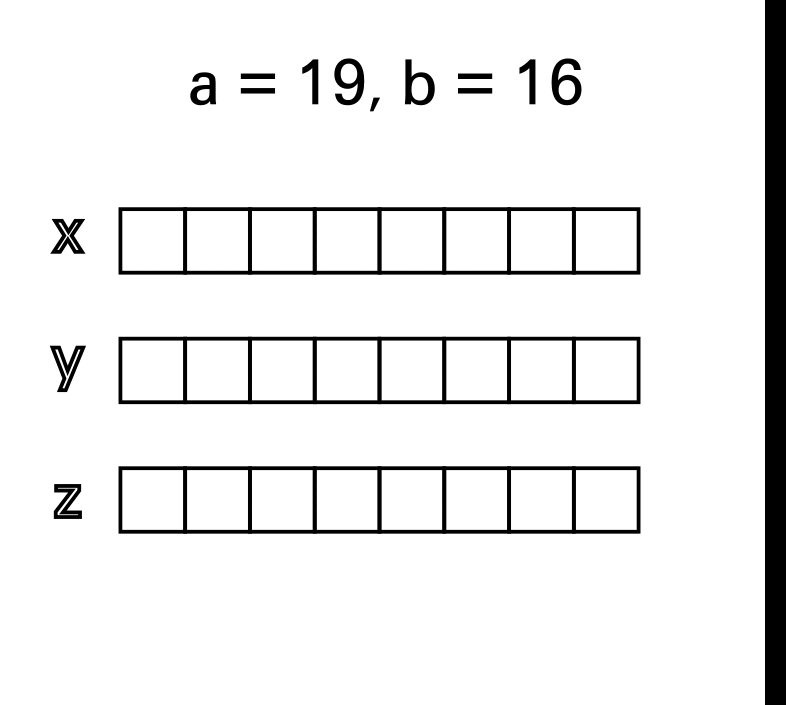

---

## **Tarefa 3 - Verificação de segurança**
A terceira tarefa pedia para verificar a segurança do programa, ou seja, se o `LOC_ERROR` é acessível, dadas certas restrições de *input* ($N \le a, b \le M$).

Foi criada uma nova função `init_com_restricao` que adiciona as restrições de *input* ao estado inicial. De seguida, foi implementada uma função `bmc_para_seguranca` que pergunta ao solver:

"É possível começar no estado inicial restrito e, após **N** passos, chegar a um estado onde `loc` == `LOC_ERROR`?"

In [ ]:
def init_com_restricao(state, n_val, m_val):
    cond_init_original = init(state) 

    cond_N_M = And(
        BVULE(n_val, state['a']),
        BVULE(state['a'], m_val),
        BVULE(n_val, state['b']),
        BVULE(state['b'], m_val)
    )
    
    return And(cond_init_original, cond_N_M)

def is_error(state):
    return Equals(state['loc'], LOC_ERROR)

def bmc_para_seguranca(declare, init_restrito, trans, prop_erro, K_passos, n_val, m_val):
    estados = {
        0:'INIT', 1:'SKIP', 2:'LEFT',
        3:'RIGHT', 4:'STOP', 5:'ERROR'
    }
    
    for k in range(1, K_passos + 1):
        with Solver(name="z3") as s:
            
            states = [declare(i) for i in range(k)]

            s.add_assertion(init_restrito(states[0], n_val, m_val))

            for i in range(k - 1):
                s.add_assertion(trans(states[i], states[i+1]))

            s.add_assertion(prop_erro(states[k-1]))

            if s.solve():
                print(f"--- VIOLAÇÃO DE SEGURANÇA ENCONTRADA no passo {k} ---")
                model = s.get_model()
                for i in range(k):
                    print(f"Estado {i}:")
                    loc_val = model.get_py_value(states[i]['loc'])
                    print(f"  loc = {estados.get(loc_val, loc_val)}")
                    print(f"  a = {model.get_py_value(states[i]['a'])}")
                    print(f"  b = {model.get_py_value(states[i]['b'])}")
                    print(f"  x = {model.get_py_value(states[i]['x'])}")
                    print(f"  y = {model.get_py_value(states[i]['y'])}")
                    print(f"  z = {model.get_py_value(states[i]['z'])}")
                return
            else:
                print(f"Passo {k}: Nenhum estado de erro acessível.")
                
    print(f"\nO programa é SEGURO até {K_passos} passos para a={n_val}, b={m_val}.")

In [ ]:
nbits = 16
N_PASSOS = 10
VALOR_N = BV(10, nbits)
VALOR_M = BV(30, nbits)
bmc_para_seguranca(declare, init_com_restricao, trans,is_error,N_PASSOS,VALOR_N,VALOR_M)

Passo 1: Nenhum estado de erro acessível.
Passo 2: Nenhum estado de erro acessível.
Passo 3: Nenhum estado de erro acessível.
Passo 4: Nenhum estado de erro acessível.
Passo 5: Nenhum estado de erro acessível.
Passo 6: Nenhum estado de erro acessível.
Passo 7: Nenhum estado de erro acessível.
Passo 8: Nenhum estado de erro acessível.
Passo 9: Nenhum estado de erro acessível.
Passo 10: Nenhum estado de erro acessível.

O programa é SEGURO até 10 passos para a=10_16, b=30_16.


In [ ]:
nbits = 8
N_PASSOS = 10
VALOR_N = BV(10, nbits)
VALOR_M = BV(30, nbits)
bmc_para_seguranca(declare, init_com_restricao, trans,is_error,N_PASSOS,VALOR_N,VALOR_M)

Passo 1: Nenhum estado de erro acessível.
Passo 2: Nenhum estado de erro acessível.
Passo 3: Nenhum estado de erro acessível.
Passo 4: Nenhum estado de erro acessível.
Passo 5: Nenhum estado de erro acessível.
Passo 6: Nenhum estado de erro acessível.
Passo 7: Nenhum estado de erro acessível.
Passo 8: Nenhum estado de erro acessível.
Passo 9: Nenhum estado de erro acessível.
--- VIOLAÇÃO DE SEGURANÇA ENCONTRADA no passo 10 ---
Estado 0:
  loc = INIT
  a = 23
  b = 16
  x = 23
  y = 16
  z = 0
Estado 1:
  loc = SKIP
  a = 23
  b = 16
  x = 23
  y = 16
  z = 0
Estado 2:
  loc = LEFT
  a = 23
  b = 16
  x = 23
  y = 16
  z = 0
Estado 3:
  loc = SKIP
  a = 23
  b = 16
  x = 46
  y = 8
  z = 0
Estado 4:
  loc = LEFT
  a = 23
  b = 16
  x = 46
  y = 8
  z = 0
Estado 5:
  loc = SKIP
  a = 23
  b = 16
  x = 92
  y = 4
  z = 0
Estado 6:
  loc = LEFT
  a = 23
  b = 16
  x = 92
  y = 4
  z = 0
Estado 7:
  loc = SKIP
  a = 23
  b = 16
  x = 184
  y = 2
  z = 0
Estado 8:
  loc = LEFT
  a = 23
  b =

Para tamanho 16, e $10 \le a,b \le 30$, o sistema mostrou-se seguro porém para `nbits` = 8...

Resultado: *--- VIOLAÇÃO DE SEGURANÇA ENCONTRADA no passo 10 ---*

O *solver* encontrou um contra-exemplo:

*Inputs*: `a` = 19, `b` = 16

Causa: O resultado esperado, $19 \times 16 = 304$, excede o valor máximo de 8 bits (255).

Traço do Erro: O output da execução mostrou o progresso:...
Estado 7 (*SKIP*): x = 152, y = 2

Estado 8 (*LEFT*): x = 152, y = 2

---

A transição de *LEFT* tenta calcular x = x << 1 (ou seja, $152 \times 2 = 304$).
 Este valor excede 255. A nossa condição de overflow `(BVULT(BVAdd(curr['x'], curr['x']), curr['x']))` detetou isto. 

---

Estado 9 (*ERROR*): x = 48, y = 1 (onde 48 é $304 \pmod{256}$).

A análise foi bem-sucedida e provou que o programa não é seguro para inputs que gerem cálculos intermédios (neste caso, em x) que excedam a capacidade de nbits.